In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
years = range(2013, 2024)
dfs = []

for year in years:
    temp = pd.read_csv(f"BENE_AGE_{year}.csv")
    temp['Year'] = year
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

In [10]:
print((df['Tot_Benes'] == 0).sum())

0


In [3]:
# spend per beneficiary
df['Spend_per_Bene'] = df['Tot_Mdcr_Pymt_Amt'] / df['Tot_Benes']

In [4]:
df['Log_Spend_per_Bene'] = np.log1p(df['Spend_per_Bene'])

In [7]:
df.groupby('Year')['Log_Spend_per_Bene'].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2013,956251.0,5.185661,0.899554,0.0,4.623536,5.171990,5.751383,13.538867
2014,986657.0,5.204433,0.898389,0.0,4.632476,5.180666,5.763084,13.474599
2015,1019377.0,5.223951,0.876493,0.0,4.642763,5.178137,5.766587,13.441814
2016,1053958.0,5.211579,0.874666,0.0,4.626568,5.153257,5.744522,12.997389
2017,1088687.0,5.205969,0.876249,0.0,4.617423,5.141854,5.734508,13.588751
2018,1121462.0,5.213012,0.882730,0.0,4.621075,5.140284,5.740062,13.286074
2019,1155870.0,5.230690,0.890365,0.0,4.633367,5.153569,5.759674,13.619902
2020,1161542.0,5.226663,0.913066,0.0,4.627535,5.135132,5.747520,13.351462
2021,1198754.0,5.287734,0.917478,0.0,4.685557,5.201863,5.820351,13.577806


In [8]:
df.groupby('Year')['Log_Spend_per_Bene'].median()

Year
2013    5.171990
2014    5.180666
2015    5.178137
2016    5.153257
2017    5.141854
2018    5.140284
2019    5.153569
2020    5.135132
2021    5.201863
2022    5.174273
2023    5.205236
Name: Log_Spend_per_Bene, dtype: float64

In [9]:
for year in sorted(df['Year'].unique()):
    sub = df[df['Year'] == year]
    corr = sub[['Log_Spend_per_Bene', 'Bene_Avg_Age']].corr().iloc[0,1]
    print(f"{year}: {corr:.3f}")

2013: 0.086
2014: 0.065
2015: 0.075
2016: 0.079
2017: 0.081
2018: 0.084
2019: 0.084
2020: 0.076
2021: 0.059
2022: 0.067
2023: 0.076


In [10]:
for year in sorted(df['Year'].unique()):
    sub = df[df['Year'] == year]
    corr = sub[['Log_Spend_per_Bene', 'Bene_Age_LT_65_Cnt']].corr().iloc[0,1]
    print(f"{year}: {corr:.3f}")

2013: -0.037
2014: -0.038
2015: -0.039
2016: -0.040
2017: -0.037
2018: -0.035
2019: -0.035
2020: -0.029
2021: -0.036
2022: -0.035
2023: -0.037


In [11]:
for year in sorted(df['Year'].unique()):
    sub = df[df['Year'] == year]
    corr = sub[['Log_Spend_per_Bene', 'Bene_Age_65_74_Cnt']].corr().iloc[0,1]
    print(f"{year}: {corr:.3f}")

2013: -0.020
2014: -0.020
2015: -0.021
2016: -0.021
2017: -0.019
2018: -0.018
2019: -0.019
2020: -0.015
2021: -0.027
2022: -0.020
2023: -0.019


In [12]:
for year in sorted(df['Year'].unique()):
    sub = df[df['Year'] == year]
    corr = sub[['Log_Spend_per_Bene', 'Bene_Age_75_84_Cnt']].corr().iloc[0,1]
    print(f"{year}: {corr:.3f}")

2013: -0.025
2014: -0.025
2015: -0.027
2016: -0.026
2017: -0.024
2018: -0.022
2019: -0.022
2020: -0.017
2021: -0.029
2022: -0.021
2023: -0.021


In [13]:
for year in sorted(df['Year'].unique()):
    sub = df[df['Year'] == year]
    corr = sub[['Log_Spend_per_Bene', 'Bene_Age_GT_84_Cnt']].corr().iloc[0,1]
    print(f"{year}: {corr:.3f}")

2013: -0.029
2014: -0.030
2015: -0.032
2016: -0.031
2017: -0.030
2018: -0.029
2019: -0.030
2020: -0.022
2021: -0.034
2022: -0.029
2023: -0.030


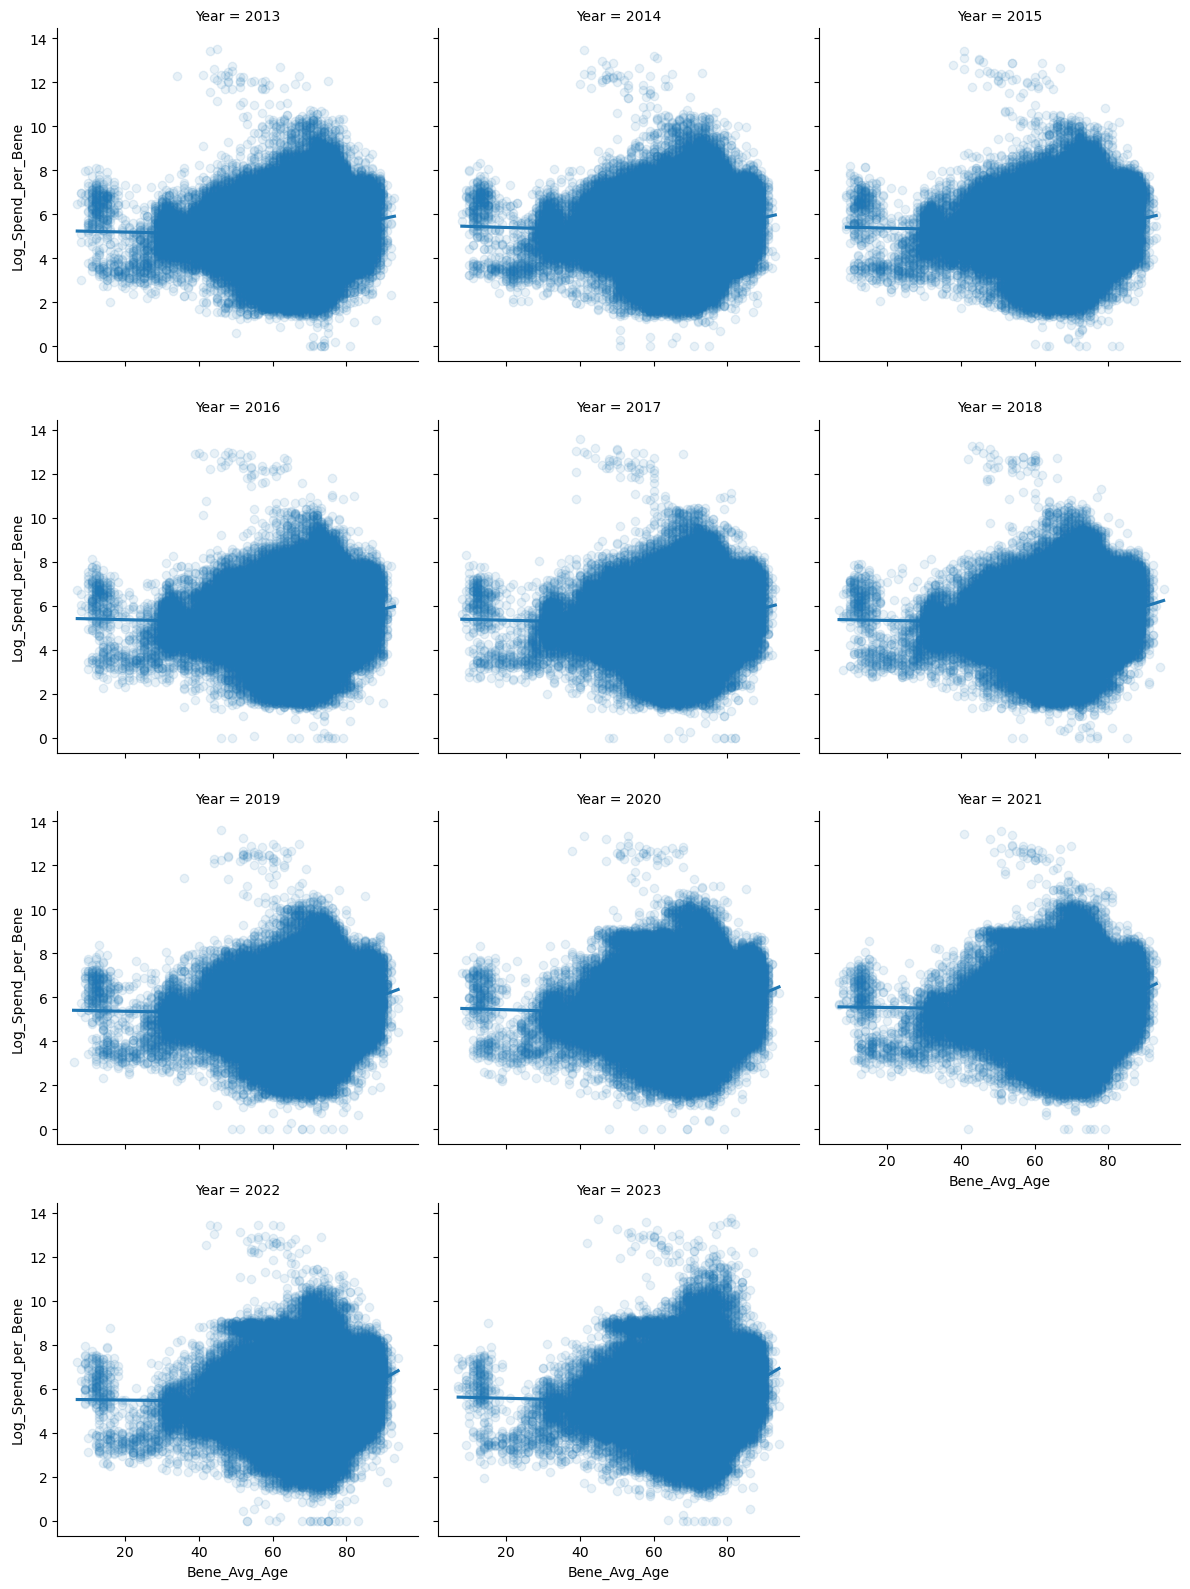

In [14]:
#sns.lmplot(
#    x='Bene_Avg_Age',
#    y='Log_Spend_per_Bene',
#    col='Year',
#    data=df,
#    lowess=True,
#    scatter_kws={'alpha':0.1},
#    col_wrap=3,
#    height=4
#)

<Axes: xlabel='Year', ylabel='Bene_Avg_Age'>

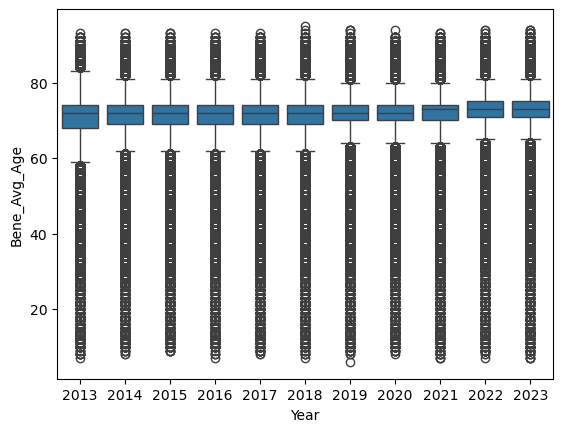

In [5]:
sns.boxplot(x='Year', y='Bene_Avg_Age', data=df)

In [5]:
df['Pct_LT65'] = df['Bene_Age_LT_65_Cnt'] / df['Tot_Benes']
df['Pct_65_74'] = df['Bene_Age_65_74_Cnt'] / df['Tot_Benes']
df['Pct_75_84'] = df['Bene_Age_75_84_Cnt'] / df['Tot_Benes']
df['Pct_GT84'] = df['Bene_Age_GT_84_Cnt'] / df['Tot_Benes']

<Axes: xlabel='Year', ylabel='Pct_GT84'>

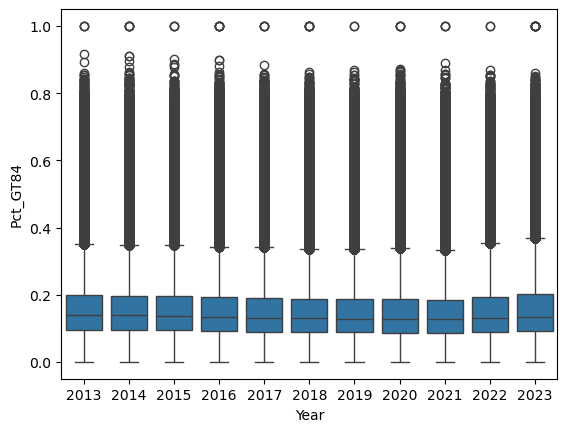

In [6]:
sns.boxplot(x='Year', y='Pct_GT84', data=df)

<Axes: xlabel='Year', ylabel='Pct_LT65'>

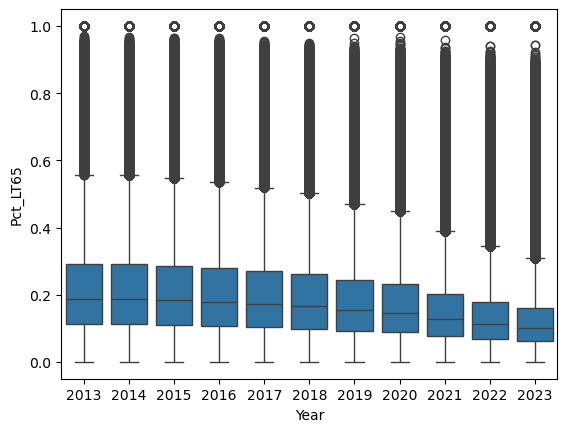

In [7]:
sns.boxplot(x='Year', y='Pct_LT65', data=df)

<Axes: xlabel='Year', ylabel='Pct_65_74'>

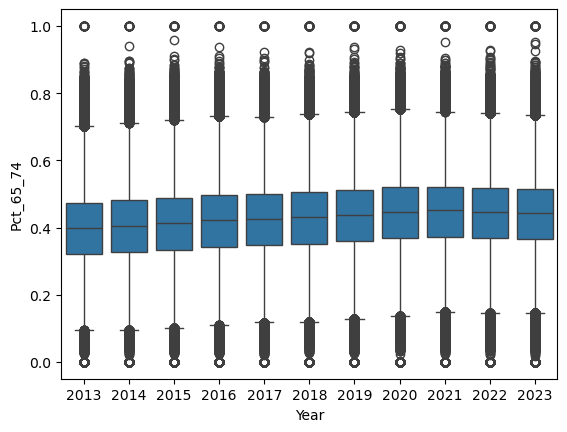

In [8]:
sns.boxplot(x='Year', y='Pct_65_74', data=df)

<Axes: xlabel='Year', ylabel='Pct_75_84'>

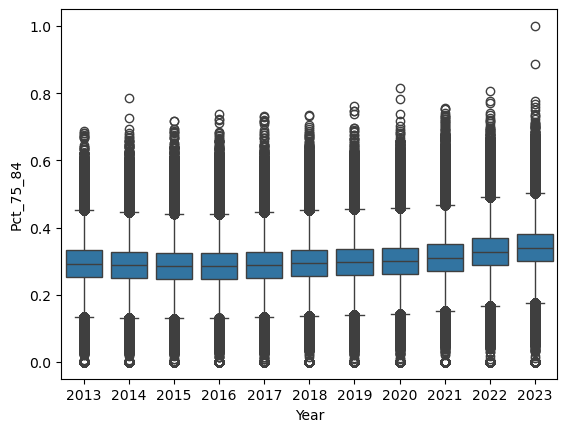

In [6]:
sns.boxplot(x='Year', y='Pct_75_84', data=df)

<Axes: xlabel='Year', ylabel='Log_Spend_per_Bene'>

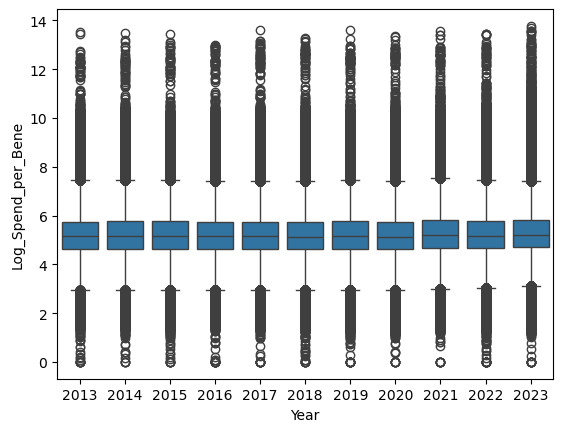

In [7]:
sns.boxplot(x='Year', y='Log_Spend_per_Bene', data=df)

<Axes: >

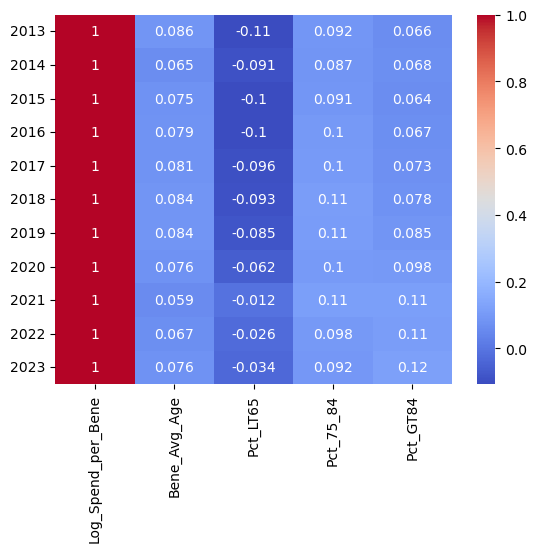

In [8]:
corrs = []

for year in sorted(df['Year'].unique()):
    sub = df[df['Year']==year]
    corr = sub[['Log_Spend_per_Bene',
                'Bene_Avg_Age',
                'Pct_LT65',
                'Pct_75_84',
                'Pct_GT84']].corr()['Log_Spend_per_Bene']
    corrs.append(corr)

corr_df = pd.DataFrame(corrs, index=sorted(df['Year'].unique()))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')